---
# Assessment 2 : Deep Learning Project — Sequence Modelling
## Deep Learning (COSC 2779 / 2792)
### Name: Sridhar Srinath (**Student ID: S4182099**)
---

**How to run:** in colab, choose runtime. Change runtime type to T4 GPU. Upload `data_2026_A2.zip` and `techniques_list_task3.txt` to the working folder. Now run the notebook.


---
Litmus Pty Ltd:
* Detecting persuasion techniques in meme text (Part A)
* Showing where (Part B)
* The product evaluation (Part C)

---
### 0. Setup

Install the libraries and import that are necessary for this notebook.

In [2]:
# Filter out warnings
import warnings
warnings.filterwarnings('ignore')

In [3]:
!pip install -q "transformers>=4.30.0" "peft>=0.4.0" "huggingface_hub>=0.14.1" accelerate

In [4]:
# Importing all the necessary libraries
import os
import re
import math
import glob
import json
import torch
import random
import zipfile
import numpy as np
import pandas as pd
import transformers
import seaborn as sns
import torch.nn as nn
import matplotlib.pyplot as plt


In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device, ',', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU only')
print('torch', torch.__version__, ', transformers', transformers.__version__)

Using device: cuda , Tesla T4
torch 2.10.0+cu128 , transformers 5.19.0


### **Fixed random seed (Reproducibility)**

Every source of randomness is seeded: Python, NumPy, PyTorch on CPU and GPU, and the shuffling of data batches. cuDNN is also set to deterministic mode.

The brief requires reproducible results. `set_seed` is called again at the start of every training run, so each experiment is reproducible on its own, not only as part of a full run.

In [6]:
SEED = 42

def set_seed(seed):
  random.seed(seed)
  np.random.seed(seed)
  torch.manual_seed(seed)
  torch.cuda.manual_seed_all(seed)
  torch.backends.cudnn.deterministic = True
  torch.backends.cudnn.benchmark = False

set_seed(SEED)

---
### 1. Data loading and integrity checks

The zip holds the SemEval-2021 Task 6 text sub-tasks. The `task1` file gives each meme's text with its set of technique labels (Part A). The `task2` file gives the same memes with character-level spans for each technique (Part B). Train and dev are combined into one development pool of 751 memes.

Both parts of the system are trained from these two files, so they must agree. The check below confirms the labels, the spans and the label list before any modelling.

The test files are not loaded here as they are saved for the future. For now, only the development pool is used.

In [10]:
# ---- Find the data folder (unzip the data zip first if needed) ----
def find(pattern):
    hits = glob.glob(f'**/{pattern}', recursive=True) + glob.glob(f'../*/{pattern}') + glob.glob(f'../*/*/{pattern}')
    return [h for h in hits if '__MACOSX' not in h]

if not find('training_set_task1*'):
    for zip_path in find('*.zip'):
        with zipfile.ZipFile(zip_path) as z:
            if any('training_set_task1' in n for n in z.namelist()):
                z.extractall('data_2026_A2_extracted')

hits = find('training_set_task1*')
print('Notebook is running in:', os.getcwd())
print('Contents:', os.listdir('.'))
assert hits, 'training_set_task1.txt not found - please share the two lines printed above'
DATA_DIR = os.path.dirname(hits[0])
print('Data folder:', DATA_DIR, '->', sorted(os.listdir(DATA_DIR)))

Notebook is running in: /home/ec2-user/SageMaker/DL-2026-A2
Contents: ['data_2026_A2', '.git', 's4182099-A2.ipynb', '.ipynb_checkpoints']
Data folder: data_2026_A2/data -> ['.ipynb_checkpoints', 'dev_set_task1.txt', 'dev_set_task2.txt', 'test_set_task1.txt', 'test_set_task2.txt', 'training_set_task1.txt', 'training_set_task2.txt']


In [11]:
# The published taxonomy has 22 techniques (techniques_list_task3.txt).
# The last two ("Transfer", "Appeal to (Strong) Emotions") only exist for the image-based sub-task,
# so the text data uses the first 20. We verify this against the data below rather than assume it.
ALL_22 = ['Appeal to authority', 'Appeal to fear/prejudice', 'Black-and-white Fallacy/Dictatorship',
          'Causal Oversimplification', 'Doubt', 'Exaggeration/Minimisation', 'Flag-waving',
          'Glittering generalities (Virtue)', 'Loaded Language',
          "Misrepresentation of Someone's Position (Straw Man)", 'Name calling/Labeling',
          'Obfuscation, Intentional vagueness, Confusion', 'Presenting Irrelevant Data (Red Herring)',
          'Reductio ad hitlerum', 'Repetition', 'Slogans', 'Smears', 'Thought-terminating cliché',
          'Whataboutism', 'Bandwagon', 'Transfer', 'Appeal to (Strong) Emotions']

if os.path.exists('techniques_list_task3.txt'):
  ALL_22 = [l.strip() for l in open('techniques_list_task3.txt', encoding='utf-8') if l.strip()]
TECHNIQUES = ALL_22[:20]
N_LABELS = len(TECHNIQUES)
T2I = {t: i for i, t in enumerate(TECHNIQUES)}

def load_split(name):
  # Returns a list of memes: {'id', 'text', 'labels' (set), 'spans' [(start, end, technique)]}
  t1 = json.load(open(os.path.join(DATA_DIR, f'{name}_set_task1.txt'), encoding='utf-8'))
  t2 = json.load(open(os.path.join(DATA_DIR, f'{name}_set_task2.txt'), encoding='utf-8'))
  spans_by_id = {d['id']: d for d in t2}
  docs = []
  for d in t1:
    d2 = spans_by_id[d['id']]
    assert d2['text'] == d['text'], 'text mismatch between task1 and task2'
    spans = [(s['start'], s['end'], s['technique']) for s in d2['labels']]
    docs.append({'id': d['id'], 'text': d['text'], 'labels': set(d['labels']), 'spans': spans})
  return docs

train_docs = load_split('training')
dev_docs   = load_split('dev')
pool_docs  = train_docs + dev_docs
# development pool used for all design decisions
print(f'train: {len(train_docs)}, dev: {len(dev_docs)}, development pool: {len(pool_docs)}')

# Integrity checks
used = set(l for d in pool_docs for l in d['labels'])
print('Techniques used in the data:', len(used), ', outside the 20-label list:', used - set(TECHNIQUES))
consistent = sum(d['labels'] == set(s[2] for s in d['spans']) for d in pool_docs)
print(f'Memes whose label set equals the union of their span techniques: {consistent}/{len(pool_docs)}')
bad_offsets = sum(1 for d in pool_docs for s, e, t in d['spans'] if not (0 <= s < e <= len(d['text'])))
print('Spans with invalid offsets:', bad_offsets)
dup_texts = len(pool_docs) - len(set(d['text'].strip().lower() for d in pool_docs))
print('Exact duplicate texts inside the pool:', dup_texts)

train: 688, dev: 63, development pool: 751
Techniques used in the data: 20 , outside the 20-label list: set()
Memes whose label set equals the union of their span techniques: 751/751
Spans with invalid offsets: 0
Exact duplicate texts inside the pool: 2


**What the checks show.**

* All 751 memes have a label set that is exactly the union of the techniques of their spans. Part A labels can be derived from Part B spans, so one annotation underlines both tasks.
* Exactly 20 of 22 published techniques occur in the text data, confirming a 20-label output space. The remaining two (Transfer, Appeal to (Strong) Emotions) belong to the image-based sub-task.
* No span has invalid character offset.
* Two exact duplicate texts exist inside the pool. They are kept: removing them woild change the official splits, and two memes out of 751 cannot noticeably bias training.

---
### 2. Exploratory data analysis
Each analysis below ends with the design decision it leads to.

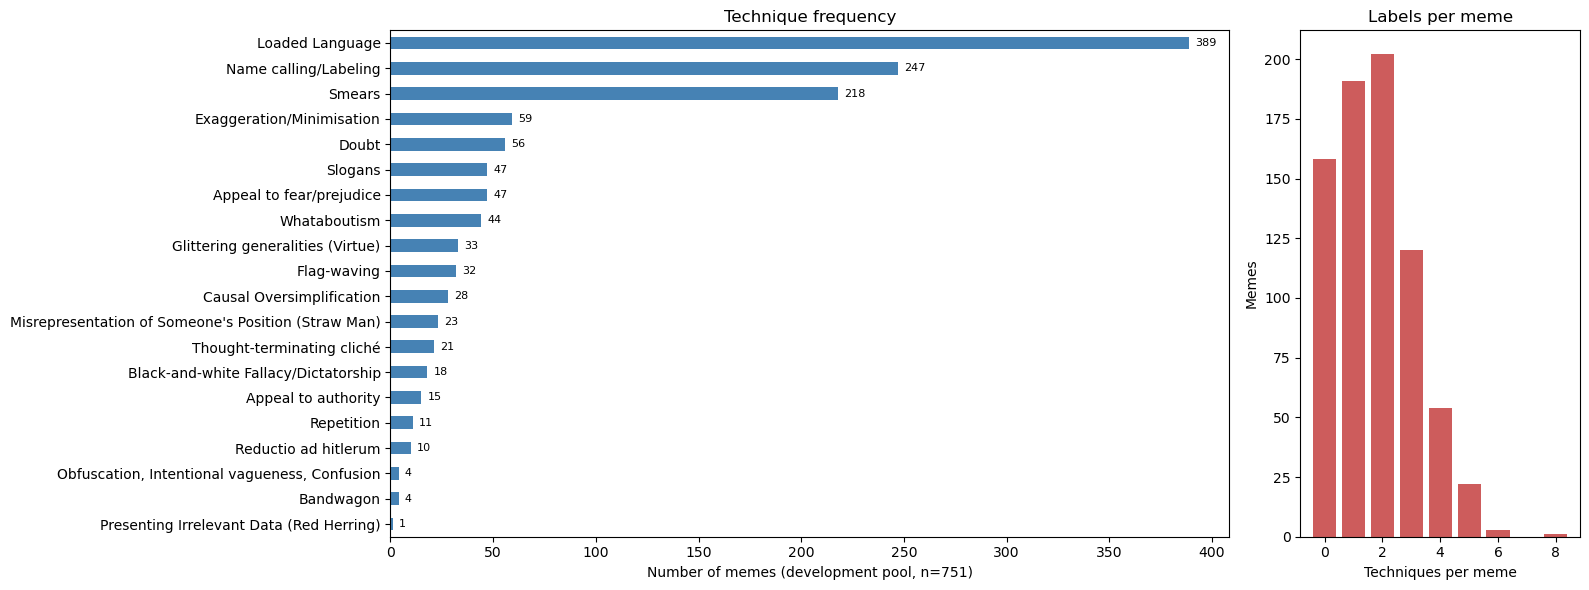

Imbalance: most frequent / least frequent = 389 / 1
Techniques with < 10 memes: ['Obfuscation, Intentional vagueness, Confusion', 'Bandwagon', 'Presenting Irrelevant Data (Red Herring)']
Memes with no technique: 158 (21%); mean labels per meme: 1.74


In [12]:
Y_pool = np.array([[1 if t in d['labels'] else 0 for t in TECHNIQUES] for d in pool_docs])
counts = pd.Series(Y_pool.sum(0), index=TECHNIQUES).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={'width_ratios': [3, 1]})
counts.plot.barh(ax=axes[0], color='steelblue')
axes[0].invert_yaxis()
axes[0].set_xlabel('Number of memes (development pool, n=751)')
axes[0].set_title('Technique frequency')
for i, v in enumerate(counts.values):
    axes[0].text(v + 3, i, str(v), va='center', fontsize=8)
n_per_meme = Y_pool.sum(1)
axes[1].bar(*np.unique(n_per_meme, return_counts=True), color='indianred')
axes[1].set_xlabel('Techniques per meme')
axes[1].set_ylabel('Memes'); axes[1].set_title('Labels per meme')
plt.tight_layout()
plt.show()

print(f'Imbalance: most frequent / least frequent = {counts.max()} / {counts.min()}')
print('Techniques with < 10 memes:', list(counts[counts < 10].index))
print(f'Memes with no technique: {(n_per_meme == 0).sum()} ({(n_per_meme == 0).mean():.0%}); mean labels per meme: {n_per_meme.mean():.2f}')

*Findings:*
* **Extreme imbalance.** Loaded Language appears in 389 of 751 memes. Obfuscation, Bandwagon and Red Herring appear in fewer than 10, and Red Herring in only one. This leads to two decisions:
  * the primary metric must not let the three big techniques hide failure on the rest.
  * an imbalance remedy (positive-class weighting in the loss)
* **Genuinely multi-label.** Memes carry between 0 and 8 techniques (mean 1.74), and 158 memes (21%) carry none. The output therefore uses an independent sigmoid per technique, trained with binary cross-entropy. A softmax would force exactly one answer and could never say "none".
* **Rare techniques cannot be measured reliably.** With only a handful of examples, any F1 score for these labels has a very wide error bar.

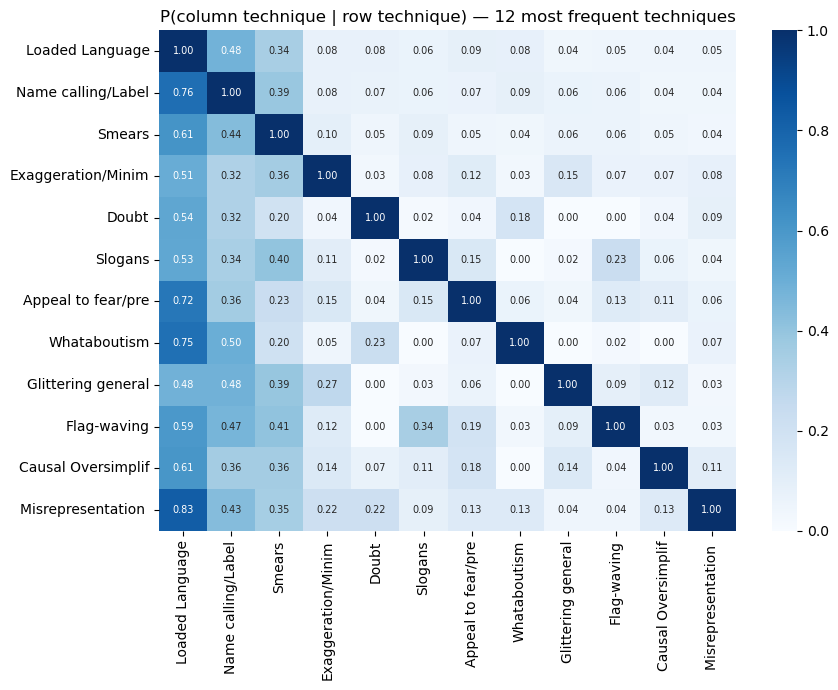

In [13]:
# Co-occurence with techniques appear together?
co = Y_pool.T @ Y_pool
top = counts.index[:12]
idx = [T2I[t] for t in top]
co_norm = co[np.ix_(idx, idx)] / np.maximum(np.diag(co)[idx][:, None], 1)   # P(column | row)
plt.figure(figsize=(9, 7))
sns.heatmap(co_norm, xticklabels=[t[:18] for t in top], yticklabels=[t[:18] for t in top], cmap='Blues', annot=True, fmt='.2f', annot_kws={'size': 7})
plt.title('P(column technique | row technique) — 12 most frequent techniques')
plt.tight_layout()
plt.show()

*Findings:*

Techniques co-occur stronly. For example, a meme with Name calling very often also has Loaded Language and Smears. A model with one shared representation and a joint multi-label output can use these correlations, so this supports one multi-label head rather than 20 separate classifiers.

Risk to watch, the same correlation can make the model raise these techniques together even when only one is present.

,spans,median_words,share_covering_>80%_of_text
Loaded Language,611,1.0,0.00
Name calling/Labeling,338,2.0,0.02
Smears,221,15.0,0.64
Exaggeration/Minimisation,66,5.0,0.12
Doubt,58,11.5,0.41
Slogans,52,3.0,0.12
Appeal to fear/prejudice,50,8.5,0.10
Whataboutism,44,23.0,0.70
Repetition,41,2.0,0.00
Flag-waving,38,4.0,0.03


Tagged characters covered by 2+ techniques at once: 36%
Memes with at least one overlapping region: 373/751


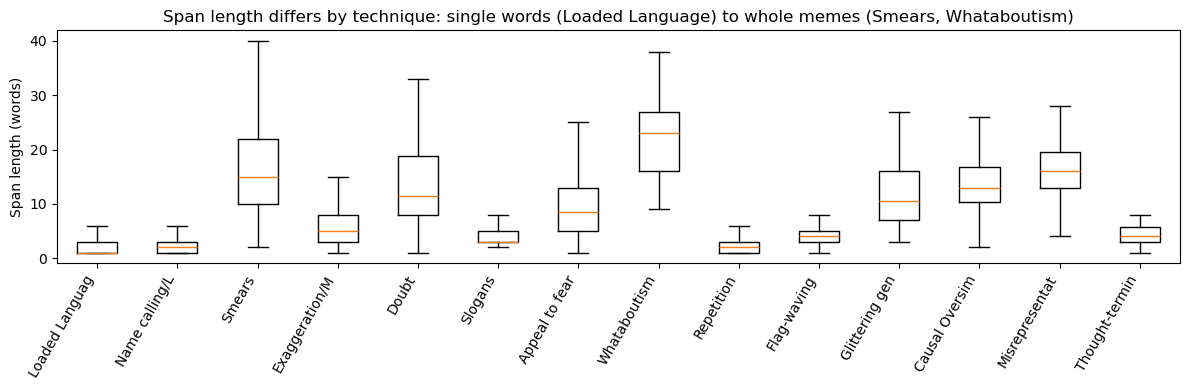

In [14]:
# Span properties: length per technique, and how often the same words carry 2+ techniques
from collections import defaultdict, Counter
span_words = defaultdict(list)
whole_text = Counter()
n_spans = Counter()
tagged_chars, overlap_chars, docs_with_overlap = 0, 0, 0
for d in pool_docs:
    text = d['text']
    char_techs = [set() for _ in text]
    for s, e, t in d['spans']:
        span_words[t].append(len(text[s:e].split()))
        n_spans[t] += 1
        if (e - s) >= 0.8 * len(text.rstrip()):
            whole_text[t] += 1
        for i in range(s, min(e, len(text))):
            char_techs[i].add(t)
    tagged = sum(1 for i, ts in enumerate(char_techs) if ts and not text[i].isspace())
    over = sum(1 for i, ts in enumerate(char_techs) if len(ts) > 1 and not text[i].isspace())
    tagged_chars += tagged; overlap_chars += over; docs_with_overlap += (over > 0)

span_df = pd.DataFrame({'spans': pd.Series(n_spans), 'median_words': pd.Series({t: np.median(v) for t, v in span_words.items()}),
                        'share_covering_>80%_of_text': pd.Series({t: whole_text[t] / n_spans[t] for t in n_spans})}).sort_values('spans', ascending=False).round(2)
display(span_df)
print(f'Tagged characters covered by 2+ techniques at once: {overlap_chars / tagged_chars:.0%}')
print(f'Memes with at least one overlapping region: {docs_with_overlap}/{len(pool_docs)}')

plt.figure(figsize=(12, 4))
order = span_df.index[:14]
plt.boxplot([span_words[t] for t in order], showfliers=False)
plt.xticks(range(1, len(order) + 1), [t[:14] for t in order], rotation=60, ha='right'); plt.ylabel('Span length (words)')
plt.title('Span length differs by technique: single words (Loaded Language) to whole memes (Smears, Whataboutism)')
plt.tight_layout(); plt.show()

*Findings:*
* **Overlap is the norm.** 36 % of all tagged characters belong to two or more techniques at once, in 373 of 751 memes. Standard named-entity tagging cannot represent this. The span head therefore predicts 20 independent yes/no outputs per token, so overlaps are handled naturally.
* **Span length depends on the technique.**
  * Loaded Language spans are typically one word (median 1), and Name calling two.
  * Smears (median 15 words; 64 % cover over 80 % of the meme), Whataboutism (70 %) and Appeal to authority (87 %) usually cover almost the whole meme.

  A tagger needs context from the encoder to handle both kinds.
* **Consequence for evaluation:** because many spans cover the whole meme, a "highlight everything" strategy can look good on a character-overlap metric. Therefore adds a baseline that paints the model's own labels over the whole text, and the span head is only worth having if it beats that.

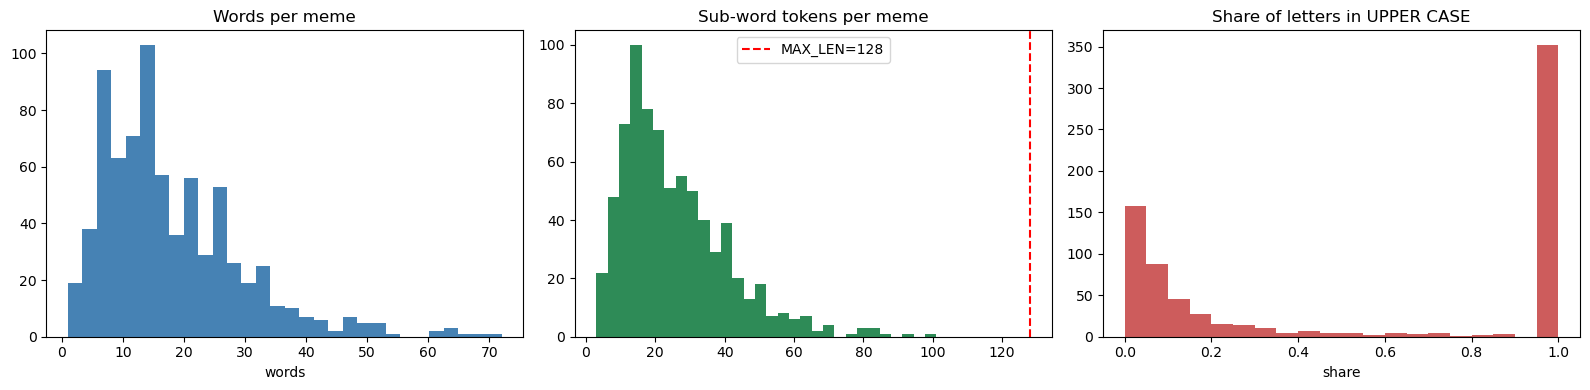

Words: median 15, 95th pct 39, max 72
Tokens: 99th pct 79, max 101 -> memes truncated at MAX_LEN: 0
Memes written mostly in capitals (>70% upper-case letters): 48%


In [16]:
# Text length in words and in DistilBERT sub-word tokens; casing; topical vocabulary
from transformers import AutoTokenizer, AutoModel

ENCODER_NAME = 'distilbert-base-uncased' # justified in Section 4
MAX_LEN = 128 # checked against real token lengths in Section 2

tokenizer = AutoTokenizer.from_pretrained(ENCODER_NAME)
n_words = np.array([len(d['text'].split()) for d in pool_docs])
n_tokens = np.array([len(tokenizer(d['text'])['input_ids']) for d in pool_docs])
upper_share = np.array([sum(c.isupper() for c in d['text']) / max(1, sum(c.isalpha() for c in d['text'])) for d in pool_docs])

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].hist(n_words, bins=30, color='steelblue')
axes[0].set_title('Words per meme'); axes[0].set_xlabel('words')
axes[1].hist(n_tokens, bins=30, color='seagreen')
axes[1].axvline(MAX_LEN, color='red', ls='--', label=f'MAX_LEN={MAX_LEN}')
axes[1].set_title('Sub-word tokens per meme')
axes[1].legend()
axes[2].hist(upper_share, bins=20, color='indianred')
axes[2].set_title('Share of letters in UPPER CASE')
axes[2].set_xlabel('share')
plt.tight_layout(); plt.show()
print(f'Words: median {np.median(n_words):.0f}, 95th pct {np.percentile(n_words, 95):.0f}, max {n_words.max()}')
print(f'Tokens: 99th pct {np.percentile(n_tokens, 99):.0f}, max {n_tokens.max()} -> memes truncated at MAX_LEN: {(n_tokens > MAX_LEN).sum()}')
print(f'Memes written mostly in capitals (>70% upper-case letters): {(upper_share > 0.7).mean():.0%}')

*Findings:*
* **Length.** Memes are short: a median of 15 words, and at most 101 sub-word tokens. `MAX_LEN = 128` covers every meme with no truncation, so no span is lost, and inputs are short enough for a fast forward pass.
* **Casing.** 48 % of memes are written mostly in capitals. A *cased* encoder would treat "LIBERALS" and "liberals" as different, rarer tokens. An uncased encoder maps both to the same token, so uncased models are used throughout. This is a property of meme text that a news-text setting would not have.

In [17]:
# Where does this corpus come from, topically? (keyword counts for ANALYSIS only)
topic_terms = {
    'Trump': r'\btrump', 'Biden': r'\bbiden', 'Obama': r'\bobama', 'Hillary/Clinton': r'\bhillary|\bclinton',
    'Democrat/liberal/left': r'\bdemocrat|\bdems?\b|\bliberal|\bleftist', 'Republican/conservative/GOP': r'\brepublican|\bgop\b|\bconservative',
    'COVID/virus/mask': r'covid|corona|virus|\bmasks?\b', 'America/USA': r'america|\busa\b',
    'Australia (any AU term)': r'australia|aussie|albanese|dutton|morrison|\blabor\b'}
topic_counts = {k: sum(bool(re.search(p, d['text'].lower())) for d in pool_docs) for k, p in topic_terms.items()}
display(pd.DataFrame({'memes': topic_counts, 'share': {k: v / len(pool_docs) for k, v in topic_counts.items()}}).round(3))
us_any = sum(bool(re.search('|'.join(list(topic_terms.values())[:-1]), d['text'].lower())) for d in pool_docs)
print(f'Memes mentioning at least one US-political / COVID term: {us_any}/{len(pool_docs)} ({us_any/len(pool_docs):.0%})')

,memes,share
Trump,100,0.133
Biden,46,0.061
Obama,6,0.008
Hillary/Clinton,14,0.019
Democrat/liberal/left,70,0.093
Republican/conservative/GOP,13,0.017
COVID/virus/mask,55,0.073
America/USA,65,0.087
Australia (any AU term),1,0.001


Memes mentioning at least one US-political / COVID term: 280/751 (37%)


### Data provenance (Dimitrov et al., 2021) and what it means here
* **Where and when.** The SemEval-2021 Task 6 authors collected English memes during 2020 from 26 public Facebook groups. Of these, 23 were mainly US/Canadian political groups spanning left, right, centrist, anti-government and gun-control communities. The other three covered broader topics such as health/COVID-19, vaccines and gender equality.
* **Who annotated, and how.** The annotation team had six English-fluent members from several nationalities and educational backgrounds. For the text annotations used in Parts A and B, three annotators labelled each example independently, including the spans. They then met with the rest of the team in a consolidation stage and discussed disagreements until a consensus gold annotation was reached.
* **What the data itself shows (computed above):** 37 % of development memes name a US politician or party, or COVID. Trump alone appears in 13 %. Exactly one meme in 751 mentions anything Australian.
* **Risks that shape the design and Part C:**
  1. **Topic/entity shortcut.** With about 750 examples, a model can learn "mentions Biden/Trump → *Name calling*/*Smears*" instead of the *form* of the technique. → C1 counterfactual name swap; C4 Australian-ised test set.
  2. **Distribution shift** to 2026 Australian teen feeds: different politicians, slang and topics. → C4.
  3. **Label subjectivity.** The gold labels are consensus decisions, not objective facts. Borderline techniques (e.g. *Doubt*, *Smears*) admit more than one plausible reading. → The tool should present labels as *prompts for discussion*, not verdicts (§10).
* **Additional public training data: none was added.** Other propaganda corpora either use overlapping taxonomies whose labels could leak into this evaluation set, or come from a different genre (news articles). With three weeks to deployment, declaring, cleaning and de-duplicating them against the test set was not justified. This is listed as future work.
* **Data augmentation: not used for training.** Text augmentations such as synonym replacement or back-translation can change the persuasion technique (swapping "traitor" for "opponent" removes Loaded Language), so they are not reliably label-preserving here. The controlled edits in C1 and C4 are evaluation stress tests only.

---
### 3. Evaluation framework

#### 3.1 Metrics

**Part A primary metric: macro-F1 over techniques.** This is the F1 per technique, averaged over the techniques that occur in the evaluation set. One number is used for every selection decision and for the targets.

**Why macro-F1, and not micro-F1 or accuracy?** The tool's purpose is to *teach every technique*, not to recognise the three common ones. The baseline table below shows the danger concretely: a "model" that always outputs the three most frequent techniques reaches micro-F1 0.48 but macro-F1 0.08. Micro-F1 would rate that useless model as half-good. So would accuracy, which is dominated by the many easy "absent" decisions. Macro-F1 does not.

*Secondary, reported but never used to select:* micro-F1 (it eases comparison with other work), plus per-technique precision and recall.

**Part B metric: character-level span F1.** For every meme and technique, the set of predicted characters is compared with the set of gold characters (whitespace ignored). TP/FP/FN characters are counted, and **macro** (primary, for consistency with Part A) and micro averages are reported. This gives partial credit for partial overlap, which suits the use case: highlighting most of the right words is still useful to a student.

In [18]:
def doc_scores(Y_true, Y_pred):
    # Multi-label scores. Y_* are 0/1 arrays of shape (n_memes, 20).
    Y_true = np.asarray(Y_true); Y_pred = np.asarray(Y_pred)
    tp = (Y_true * Y_pred).sum(0); fp = ((1 - Y_true) * Y_pred).sum(0); fn = (Y_true * (1 - Y_pred)).sum(0)
    f1 = np.where(2 * tp + fp + fn > 0, 2 * tp / np.maximum(2 * tp + fp + fn, 1), 0.0)
    precision = np.where(tp + fp > 0, tp / np.maximum(tp + fp, 1), 0.0)
    recall = np.where(tp + fn > 0, tp / np.maximum(tp + fn, 1), 0.0)
    present = Y_true.sum(0) > 0 # macro over techniques that occur in this set
    micro = 2 * tp.sum() / max(2 * tp.sum() + fp.sum() + fn.sum(), 1)
    return {'macro_f1': f1[present].mean(), 'micro_f1': micro, 'f1': f1, 'precision': precision, 'recall': recall, 'support': Y_true.sum(0)}

def char_sets(text, spans):
    # technique -> set of non-whitespace character positions covered
    out = defaultdict(set)
    for s, e, t in spans:
        for i in range(s, min(e, len(text))):
            if not text[i].isspace():
                out[t].add(i)
    return out

def span_scores(docs, pred_spans):
    # Character-level span F1. pred_spans[i] = list of (start, end, technique) for docs[i]
    tp, fp, fn = Counter(), Counter(), Counter()
    for d, preds in zip(docs, pred_spans):
        gold = char_sets(d['text'], d['spans']); pred = char_sets(d['text'], preds)
        for t in TECHNIQUES:
            tp[t] += len(gold[t] & pred[t]); fp[t] += len(pred[t] - gold[t]); fn[t] += len(gold[t] - pred[t])
    f1 = {t: (2 * tp[t] / (2 * tp[t] + fp[t] + fn[t]) if (2 * tp[t] + fp[t] + fn[t]) > 0 else 0.0) for t in TECHNIQUES}
    present = [t for t in TECHNIQUES if tp[t] + fn[t] > 0]
    T, FP, FN = sum(tp.values()), sum(fp.values()), sum(fn.values())
    return {'macro_f1': np.mean([f1[t] for t in present]), 'micro_f1': 2 * T / max(2 * T + FP + FN, 1), 'f1': f1}

def labels_to_matrix(label_sets):
    return np.array([[1 if t in s else 0 for t in TECHNIQUES] for s in label_sets])

#### 3.2 Trivial baselines (computed on the development pool)

Score simple rules that use model at all. They Give chance/majority floor that targets are built from. A model that cannot clearly beat them has learned nothing useful.

In [19]:
freq_order = list(counts.index)          # techniques sorted by frequency in the pool
baseline_rows = []
for name, labels in [('Predict all 20 techniques', set(TECHNIQUES)),
                     ('Always predict top-1 (Loaded Language)', set(freq_order[:1])),
                     ('Always predict top-3 frequent', set(freq_order[:3]))]:
    s = doc_scores(Y_pool, labels_to_matrix([labels] * len(pool_docs)))
    baseline_rows.append((name, s['macro_f1'], s['micro_f1']))
rng = np.random.default_rng(SEED); prior = Y_pool.mean(0)
rand = [doc_scores(Y_pool, (rng.random(Y_pool.shape) < prior).astype(int)) for _ in range(200)]
baseline_rows.append(('Random, at each technique\'s base rate (200 draws)', np.mean([r['macro_f1'] for r in rand]), np.mean([r['micro_f1'] for r in rand])))
baseline_A = pd.DataFrame(baseline_rows, columns=['Part A baseline', 'macro-F1', 'micro-F1']).round(3)
display(baseline_A)

# Part B baselines: highlight the whole meme
whole = lambda d, labs: [(0, len(d['text']), t) for t in labs]
rows = []
for name, fn_labels in [('Whole text, all 20 techniques', lambda d: TECHNIQUES),
                        ('Whole text, top-3 frequent techniques', lambda d: freq_order[:3]),
                        ('Whole text, GOLD labels (oracle labels, no localisation)', lambda d: d['labels'])]:
    s = span_scores(pool_docs, [whole(d, fn_labels(d)) for d in pool_docs])
    rows.append((name, s['macro_f1'], s['micro_f1']))
baseline_B = pd.DataFrame(rows, columns=['Part B baseline', 'char macro-F1', 'char micro-F1']).round(3)
display(baseline_B)
BEST_TRIVIAL_MACRO_A = baseline_A['macro-F1'].iloc[:4].max()
BEST_TRIVIAL_MACRO_B = baseline_B['char macro-F1'].iloc[:2].max()   # oracle row excluded: it uses gold labels
BEST_TRIVIAL_MICRO_A = baseline_A['micro-F1'].max()
print('Best trivial macro-F1  Part A:', round(BEST_TRIVIAL_MACRO_A, 3), '| Part B:', round(BEST_TRIVIAL_MACRO_B, 3))

,Part A baseline,macro-F1,micro-F1
0,Predict all 20 techniques,0.139,0.160
1,Always predict top-1 (Loaded Language),0.034,0.378
2,Always predict top-3 frequent,0.081,0.480
3,"Random, at each technique's base rate (200 draws)",0.087,0.284


,Part B baseline,char macro-F1,char micro-F1
0,"Whole text, all 20 techniques",0.078,0.084
1,"Whole text, top-3 frequent techniques",0.040,0.247
2,"Whole text, GOLD labels (oracle labels, no loc...",0.619,0.576


Best trivial macro-F1  Part A: 0.139 | Part B: 0.078


#### 3.4 Numeric targets — fixed here, before any model is trained

| | Minimum to be useful at all | Deployment target (unsupervised classroom use) |
|---|---|---|
| **Part A macro-F1** | **≥ 0.28** = 2 × best trivial macro-F1 (0.139, "predict all 20") | **≥ 0.50** |
| Part A micro-F1 (guard) | must beat the "always top-3" baseline (0.480 on the pool) | — |
| **Part B char macro-F1** | **≥ 0.16** = 2 × best label-free trivial (0.078) **and** must beat the model's *own labels painted on the whole text* | **≥ 0.40** |

**Justification**
* **Minimum (floor-based).** Twice the best trivial macro-F1 means the model must find techniques clearly better than guessing everything. Without that, its labels carry little information for a teacher. The micro-F1 guard rules out a model that only looks acceptable because it keeps predicting the most frequent techniques.
* **Deployment target (operational).** In an unsupervised classroom, a wrong label actively **mis-teaches** a technique. A wrongly attached *Smears* or *Name calling* label on a meme about someone's family politics is a fairness incident. Macro-F1 ≥ 0.50 is a deliberately demanding bar for balanced per-technique quality. It does **not** imply that precision and recall are each ≥ 0.50, so those are inspected separately wherever display decisions are made.
* **Part B.** Highlights are only useful if they point at the right words. The "own labels on the whole text" comparison tests whether the span head adds localisation beyond the labels themselves. The oracle row above shows how strongly a character metric rewards whole-text highlighting: it scores **0.62** using the **gold** labels with no localisation at all. It is **not** a target, but it warns against reading Part B numbers in isolation.

#### 3.5 Data splits — how each number is produced

* **Test set (200 memes, official test files).** Completely inaccessible during architecture, hyper-parameter and threshold selection.
* **Design decisions use 5-fold cross-validation over the 751-meme pool.** With a single 63-meme dev split, every comparison would depend on which few memes landed in it: rare techniques would have 0–3 examples, and one meme could swing macro-F1 by several points. CV evaluates every meme once and gives a **spread across folds**, so each decision rests on mean std.
* **Early stopping without re-using data.** Inside each fold, 10 % of the *training* part is set aside as an **early-stopping slice**. It is used only to pick the best epoch (the lowest slice loss; that checkpoint is restored). The **held-out fold**, never used for training or stopping, is what gets scored. The data that picks the epoch is never the data that is reported.
* **Why plain (not label-stratified) K-fold:** multi-label stratification cannot balance techniques that have 1–4 examples in the whole pool. The fold table below checks what matters instead. Every held-out fold contains 17–20 of the 20 techniques, and macro-F1 is computed only over the techniques present in each fold.
* **Like-for-like comparisons.** All configurations use the same folds and the same stopping slices, so any difference between two configurations comes from the change being tested.
* **Out-of-fold (OOF) predictions** are stored: each pool meme is predicted by the fold model that never saw it. They are used for threshold tuning, the display threshold, and the C1 bias analysis.

In [20]:
from sklearn.model_selection import KFold
N_FOLDS = 5 # cross-validation folds
STOP_FRAC = 0.10 # share of each training fold used only for early stopping

kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
FOLDS = []
for k, (tr_idx, te_idx) in enumerate(kf.split(np.arange(len(pool_docs)))):
    r = np.random.default_rng(SEED + k)
    stop_idx = np.sort(r.choice(tr_idx, size=int(STOP_FRAC * len(tr_idx)), replace=False))
    fit_idx = np.setdiff1d(tr_idx, stop_idx)
    FOLDS.append({'fit': fit_idx, 'stop': stop_idx, 'test': te_idx})

fold_table = pd.DataFrame([{'fold': k, 'fit': len(f['fit']), 'early-stop slice': len(f['stop']), 'held-out (scored)': len(f['test']), 'techniques present in held-out': int((Y_pool[f['test']].sum(0) > 0).sum())} for k, f in enumerate(FOLDS)])
display(fold_table)
for f in FOLDS:   # no overlap between the three parts of any fold
    assert not (set(f['fit']) & set(f['stop'])) and not (set(f['fit']) & set(f['test'])) and not (set(f['stop']) & set(f['test']))
print('Fold integrity check passed: fit / early-stop / held-out parts are disjoint in every fold.')

,fold,fit,early-stop slice,held-out (scored),techniques present in held-out
0,0,540,60,151,17
1,1,541,60,150,20
2,2,541,60,150,19
3,3,541,60,150,17
4,4,541,60,150,19


Fold integrity check passed: fit / early-stop / held-out parts are disjoint in every fold.


---
### 4. Model: one shared encoder, two self-built heads

**Why a pretrained transformer encoder.** Adapting a pretrained transformer is the strong, establishing starting point for small-data text classification. It beats LSTM and bag-of-embeddings models that must learn language from scratch, and 751 memes are far too few to learn English from. Development starts with DistilBERT: it keeps about 97 % of BERT's performance with 66 M parameters and is about 60 % faster. That matters for the "answer while a class waits on a T4" constraint. Its uncased vocabulary also matches the half-capitalised meme text. A larger encoder (`bert-base-uncased`) is tested to check whether capacity is the bottleneck. It was, and BERT-base is the final encoder.

**Why one joint model for Parts A and B (the brief asks for this to be justified).**
  1. **Same annotation:**
  In section 1, it showed the label set is exactly the union of the span techniques, so both heads learn from one signal. Whether sharing helps or hurts Part A is tested in tested, not assumed.
  2. **Deployment:** One encoder pass serves both heads, so latency and memory are those of a single model.
  3. **Consistency:** Both heads read the same representation, so when they disagree it reflects genuine uncertainty rather than two unrelated models.

**Why these heads.**

*

